# Gradient Boosted Survival Model
**In this notebook, we'll train and test a gradient boosting survival model from scikit-learn to predict 6 month survival from time of first line treatment for metastatic colorectal cancer.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import cumulative_dynamic_auc

import matplotlib.pyplot as plt

from utils.cv_predictions import cross_validated_survival_predictions

## Import

In [2]:
dtype_map = pd.read_csv('../outputs/1L_features_training_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
train_df = pd.read_csv('../outputs/1L_features_training.csv', dtype = dtype_map)
train_df.shape

(29907, 162)

In [3]:
dtype_map = pd.read_csv('../outputs/1L_features_testing_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
test_df = pd.read_csv('../outputs/1L_features_testing.csv', dtype = dtype_map)
test_df.shape

(7474, 162)

In [4]:
censored_before_6m = (len(train_df.query('event == 0 and duration < 180', engine = 'python'))/len(train_df))*100
censored_before_12m = (len(train_df.query('event == 0 and duration < 365', engine = 'python'))/len(train_df))*100

print(f'Percentage censored before 6 months: {round(censored_before_6m, 1)}%')
print(f'Percentage censored before 12 months: {round(censored_before_12m, 1)}%')

Percentage censored before 6 months: 6.8%
Percentage censored before 12 months: 11.9%


## Preprocess

### Selecting features

#### Categorical variables

In [5]:
list(train_df.select_dtypes(include = ['category']).columns)

['CrcSite',
 'met_diagnosis_year',
 'Ethnicity_mod',
 'Race_mod',
 'region',
 'BRAF_status',
 'KRAS_status',
 'NRAS_status',
 'MMR/MSI_status',
 'HER2_status',
 'HER2_percent_staining']

In [6]:
# Percent unknown
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns:
    value_props = train_df[var].value_counts(normalize=True)
    # Combine 'unknown' and 'Unknown' if both exist
    unknown_pct = value_props.get('unknown', 0) + value_props.get('Unknown', 0) + value_props.get('Unknown/Not documented', 0)
    var_dict[var] = round(unknown_pct*100, 3)

var_dict

{'CrcSite': 0,
 'met_diagnosis_year': 0,
 'Ethnicity_mod': 0,
 'Race_mod': 0,
 'region': np.float64(24.205),
 'BRAF_status': np.float64(49.096),
 'KRAS_status': np.float64(36.717),
 'NRAS_status': np.float64(51.821),
 'MMR/MSI_status': np.float64(34.738),
 'HER2_status': np.float64(70.418),
 'HER2_percent_staining': np.float64(99.886)}

In [7]:
# Percent positive
var_dict = {}
for var in train_df.select_dtypes(include=['category']).columns.drop(['CrcSite', 'met_diagnosis_year', 'Ethnicity_mod', 'Race_mod', 'region', 'HER2_percent_staining']):
    value_props = train_df[var].value_counts(normalize=True)
    pos_pct = value_props.get('positive', 0) + value_props.get('Positive', 0) 
    var_dict[var] = round(pos_pct*100, 3)

var_dict

{'BRAF_status': np.float64(5.557),
 'KRAS_status': np.float64(29.963),
 'NRAS_status': np.float64(2.103),
 'MMR/MSI_status': np.float64(4.601),
 'HER2_status': np.float64(1.979)}

In [8]:
categorical_var = [
    'CrcSite', 
    'BRAF_status',
    'KRAS_status',
    'NRAS_status',
    'MMR/MSI_status', 
    'HER2_status'
]

#### Binary variables 

In [9]:
list(train_df.select_dtypes(include = ['int']).columns)

['days_met_to_treatment',
 'GroupStage_mod_na',
 'age',
 'sex_male',
 'ecog_newly_gte2',
 'ecog_index_na',
 'hypotension',
 'tachycardia',
 'fevers',
 'hypoxemia',
 'anticoagulant',
 'opioid',
 'steroid',
 'antibiotic',
 'diabetic_med',
 'antidepressant',
 'bone_therapy_agent',
 'immunosuppressant',
 'chf',
 'cardiac_arrhythmias',
 'valvular_disease',
 'pulm_circulation',
 'pvd',
 'htn_uncomplicated',
 'htn_complicated',
 'paralysis',
 'other_neuro',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'pud',
 'aids_hiv',
 'lymphoma',
 'rheumatic',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'alcohol_abuse',
 'drug_abuse',
 'psychoses',
 'depression',
 'van_walraven_score',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'brain_met',
 'adrenal_met',
 'peritoneum_met',
 'gi_met',
 'other_met',
 'event']

In [10]:
# Did not include days_met_to_treatment, age, van_walraven, or event
bin_list = [
    'GroupStage_mod_na',
    'sex_male',
    'ecog_newly_gte2',
    'ecog_index_na',
    'hypotension',
    'tachycardia',
    'fevers',
    'hypoxemia',
    'anticoagulant',
    'opioid',
    'steroid',
    'antibiotic',
    'diabetic_med',
    'antidepressant',
    'bone_therapy_agent',
    'immunosuppressant',
    'chf',
    'cardiac_arrhythmias',
    'valvular_disease',
    'pulm_circulation',
    'pvd',
    'htn_uncomplicated',
    'htn_complicated',
    'paralysis',
    'other_neuro',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'pud',
    'aids_hiv',
    'lymphoma',
    'rheumatic',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'alcohol_abuse',
    'drug_abuse',
    'psychoses',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'brain_met',
    'adrenal_met',
    'peritoneum_met',
    'gi_met',
    'other_met'
]

In [11]:
# Identify binary variables with >3% prevalence 
bin_var_list = []
for bin_var in bin_list:
    if (train_df[bin_var].value_counts(normalize = True)[1] >= 0.03):
        bin_var_list.append(bin_var)

In [12]:
bin_var_list

['GroupStage_mod_na',
 'sex_male',
 'ecog_index_na',
 'tachycardia',
 'opioid',
 'steroid',
 'antibiotic',
 'cardiac_arrhythmias',
 'htn_uncomplicated',
 'chronic_pulm_disease',
 'diabetes_uncomplicated',
 'diabetes_complicated',
 'hypothyroid',
 'renal_failure',
 'liver_disease',
 'coagulopathy',
 'obesity',
 'weight_loss',
 'fluid',
 'blood_loss_anemia',
 'deficiency_anemia',
 'depression',
 'lymph_met',
 'thoracic_met',
 'liver_met',
 'bone_met',
 'peritoneum_met',
 'other_met']

In [13]:
# GroupStage_mod_na and ecog_index_na added as flags later
binary_var = [
    'sex_male',
    'tachycardia',
    'opioid',
    'steroid',
    'antibiotic',
    'cardiac_arrhythmias',
    'htn_uncomplicated',
    'chronic_pulm_disease',
    'diabetes_uncomplicated',
    'diabetes_complicated',
    'hypothyroid',
    'renal_failure',
    'liver_disease',
    'coagulopathy',
    'obesity',
    'weight_loss',
    'fluid',
    'blood_loss_anemia',
    'deficiency_anemia',
    'depression',
    'lymph_met',
    'thoracic_met',
    'liver_met',
    'bone_met',
    'peritoneum_met',
    'other_met'
]

#### Numerical variables

In [14]:
list(train_df.select_dtypes(include = ['float64']).columns)

['GroupStage_mod',
 'days_diagnosis_to_met',
 'ecog_index',
 'weight_index',
 'bmi_index',
 'percent_change_weight',
 'albumin',
 'alp',
 'alt',
 'ast',
 'bicarbonate',
 'bun',
 'calcium',
 'cea',
 'chloride',
 'creatinine',
 'hemoglobin',
 'ldh',
 'platelet',
 'potassium',
 'sodium',
 'total_bilirubin',
 'wbc',
 'albumin_max',
 'alp_max',
 'alt_max',
 'ast_max',
 'bicarbonate_max',
 'bun_max',
 'calcium_max',
 'cea_max',
 'chloride_max',
 'creatinine_max',
 'hemoglobin_max',
 'ldh_max',
 'platelet_max',
 'potassium_max',
 'sodium_max',
 'total_bilirubin_max',
 'wbc_max',
 'albumin_min',
 'alp_min',
 'alt_min',
 'ast_min',
 'bicarbonate_min',
 'bun_min',
 'calcium_min',
 'cea_min',
 'chloride_min',
 'creatinine_min',
 'hemoglobin_min',
 'ldh_min',
 'platelet_min',
 'potassium_min',
 'sodium_min',
 'total_bilirubin_min',
 'wbc_min',
 'albumin_std',
 'alp_std',
 'alt_std',
 'ast_std',
 'bicarbonate_std',
 'bun_std',
 'calcium_std',
 'cea_std',
 'chloride_std',
 'creatinine_std',
 'hemogl

In [15]:
# Added age, van_walraven_score, and days_met_to_treatment here 
numerical_var = [
    'GroupStage_mod',
    'days_diagnosis_to_met',
    'ecog_index',
    'weight_index',
    'bmi_index',
    'percent_change_weight',
    'albumin',
    'alp',
    'alt',
    'ast',
    'bicarbonate',
    'bun',
    'calcium',
    'cea',
    'chloride',
    'creatinine',
    'hemoglobin',
    'platelet',
    'potassium',
    'sodium',
    'total_bilirubin',
    'wbc',
    'alp_max',
    'alt_max',
    'ast_max',
    'calcium_max',
    'cea_max',
    'creatinine_max',
    'platelet_max',
    'potassium_max',
    'sodium_max',
    'total_bilirubin_max',
    'wbc_max',
    'albumin_min',
    'bicarbonate_min',
    'calcium_min',
    'hemoglobin_min',
    'platelet_min',
    'potassium_min',
    'sodium_min',
    'age',
    'van_walraven_score',
    'days_met_to_treatment'
]

In [16]:
all_var = categorical_var + binary_var + numerical_var

In [17]:
missing = train_df[all_var].isnull().sum()
missing[missing > 0].sort_values(ascending = False)

van_walraven_score       12468
cea                       9350
cea_max                   8652
chloride                  6727
albumin                   6115
albumin_min               5779
total_bilirubin           5697
bicarbonate               5670
calcium                   5646
alt                       5588
ast                       5498
alp                       5486
potassium                 5434
sodium                    5378
total_bilirubin_max       5365
bicarbonate_min           5342
calcium_max               5317
calcium_min               5317
alt_max                   5238
bun                       5214
ast_max                   5154
alp_max                   5137
potassium_max             5102
potassium_min             5102
creatinine                5083
sodium_max                5049
sodium_min                5049
creatinine_max            4760
percent_change_weight     3602
platelet                  3462
wbc                       3454
hemoglobin                3443
platelet

In [18]:
# Create a missing flag
for x in missing[missing > 0].index:
    train_df[f'{x}_na'] = np.where(train_df[x].isna(), 1, 0)
    test_df[f'{x}_na'] = np.where(test_df[x].isna(), 1, 0)

In [19]:
# Add missing flags to binary_var (this includes ecog_index_na and GroupStage_mod_na)
binary_var = binary_var + [col for col in train_df.columns if col.endswith('_na')]

In [20]:
all_var = categorical_var + binary_var + numerical_var

In [21]:
len(all_var)

115

### Setting up Y

In [22]:
y_dtype = [('event', bool), ('duration', float)]

In [23]:
# Death status and time until event needs to be stored as a structured array to be compatible with scikit-survival
train_y = np.array([tuple(x) for x in train_df[['event', 'duration']].values], 
                   dtype = y_dtype)

test_y = np.array([tuple(x) for x in test_df[['event', 'duration']].values], 
                  dtype = y_dtype)

### Creating mini-training set for hyperparameter tuning
**Given the computational cost of hyperparameter search on the full training set, a stratified subsample of 20,000 patients is used to identify optimal hyperparameters. The final model is then trained on the complete training set using these hyperparameters before evaluating performance on the held-out test set.**

In [24]:
train_subsample_df, _ = train_test_split(
    train_df,
    train_size = 20000,
    stratify = train_df['event'],  
    random_state = 42
)

In [25]:
train_subsample_y = np.array([tuple(x) for x in train_subsample_df[['event', 'duration']].values],
                             dtype = y_dtype)

### Creating pipeline

In [26]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

categorical_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse_output = False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numerical_var),
        ("cat", categorical_pipeline, categorical_var),
        ("pass", "passthrough", binary_var),
    ],
    remainder="drop"
)

## Train model

In [27]:
def six_month_auc_scorer_approximate(estimator, X, y):
    """
    Approximate 180d AUC using test set for censoring estimation.
    This is not ideal but may be acceptable if censoring is light (eg., <20%).
    """
    chf_funcs = estimator.predict_cumulative_hazard_function(X)
    risk_scores = np.array([chf(180) for chf in chf_funcs])
    
    # Use same y for both (not ideal, but functional)
    auc, _ = cumulative_dynamic_auc(y, y, risk_scores, 180)
    return auc[0]

auc_scorer = make_scorer(
    six_month_auc_scorer_approximate,
    greater_is_better = True,
    needs_proba = False  
)

param_distributions = {
    'model__n_estimators': [300, 500, 700],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [2, 3, 4],
    'model__subsample': [0.75, 0.85],
    'model__max_features': [0.7, 0.9]
}

gb = GradientBoostingSurvivalAnalysis(random_state = 42)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', gb)
])

search = RandomizedSearchCV(
    estimator = full_pipeline, 
    param_distributions = param_distributions, 
    n_iter = 20, 
    cv = 3,
    scoring = six_month_auc_scorer_approximate,
    refit = False,
    n_jobs = -1,
    random_state = 42,
    verbose = 1
)

search.fit(train_subsample_df[all_var], train_subsample_y)

print(f"Best params: {search.best_params_}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'model__subsample': 0.85, 'model__n_estimators': 500, 'model__max_features': 0.9, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [28]:
results_df = pd.DataFrame(search.cv_results_)
results_df.sort_values('rank_test_score', ascending = True).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__subsample,param_model__n_estimators,param_model__max_features,param_model__max_depth,param_model__learning_rate,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
18,1201.680825,23.991624,0.200780,0.009144,0.85,500,0.9,4,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.782103,0.786150,0.793524,0.787259,0.004728,1
4,1769.999899,31.414597,0.282106,0.023715,0.75,700,0.7,4,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.783142,0.784457,0.792899,0.786833,0.004323,2
7,1742.648526,76.266742,0.263230,0.025355,0.75,700,0.9,4,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.783048,0.784530,0.792368,0.786649,0.004089,3
1,1227.714368,23.370487,0.250549,0.026739,0.75,500,0.7,4,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.783507,0.784424,0.791580,0.786504,0.003609,4
15,1756.935378,2.129456,0.241889,0.007079,0.75,700,0.9,3,0.05,"{'model__subsample': 0.75, 'model__n_estimator...",0.780571,0.785085,0.791212,0.785623,0.004361,5
11,747.093950,52.405165,0.218729,0.011169,0.85,300,0.9,4,0.05,"{'model__subsample': 0.85, 'model__n_estimator...",0.779104,0.784917,0.789818,0.784613,0.004379,6
5,1278.743965,25.735597,0.251078,0.021941,0.75,500,0.7,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.779327,0.782925,0.791131,0.784461,0.004940,7
16,1236.205214,29.567080,0.212389,0.006449,0.75,500,0.9,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.777883,0.781464,0.792741,0.784029,0.006331,8
17,780.838643,24.333291,0.231776,0.051876,0.85,300,0.7,3,0.10,"{'model__subsample': 0.85, 'model__n_estimator...",0.778596,0.784646,0.788211,0.783818,0.003969,9
9,772.455275,33.644633,0.202498,0.000831,0.75,300,0.9,3,0.10,"{'model__subsample': 0.75, 'model__n_estimator...",0.775911,0.782901,0.790358,0.783057,0.005899,10


## Test model 

### Build final model 

In [29]:
best_gb_model = GradientBoostingSurvivalAnalysis(
    n_estimators = 500,  
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.85,
    max_features = 0.9,
    verbose = 1,
    random_state = 42
)

full_pipeline_final = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_gb_model)
])

full_pipeline_final.fit(train_df[all_var], train_y)

      Iter       Train Loss      OOB Improve   Remaining Time 
         1      158829.7391          17.1056           89.48m
         2      159403.1223         560.3294           88.93m
         3      158883.6419        -336.2854           88.51m
         4      158777.1228          -2.9228           88.66m
         5      158813.3167         110.9967           88.98m
         6      158606.3308         -75.4056           88.71m
         7      158634.2664          79.8057           88.64m
         8      158326.0819        -173.8207           88.55m
         9      157598.0439        -516.3891           88.20m
        10      157856.6338         270.1741           87.92m
        20      157434.7013        -220.2653           84.77m
        30      157268.2878          62.8245           82.14m
        40      156773.1837         -27.7741           79.94m
        50      156821.7648          66.8737           77.94m
        60      156631.2638        -182.3678           76.12m
       

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['GroupStage_mod',
                                                   'days_diagnosis_to_met',
                                                   'ecog_index', 'weight_index',
                                                   'bmi_index',
                                                   'percent_change_weight',
                                                   'albumin', 'alp', 'alt',
                                                   'ast', 'bicarbonate', 'bun',
                                                   'calcium', 'cea', 'chloride',
                                                   'creatinine', 'hemoglobin',
                                                   'platelet...
                                                   'blood_loss_anemia',
                                                   'deficiency_anemia',
                                                   'depression', 'lymph_met',
                                                   'thoracic_met', 'liver_met',
                                                   'bone_met', 'peritoneum_met',
                                                   'other_met',
                                                   'GroupStage_mod_na',
                                                   'ecog_index_na',
                                                   'weight_index_na',
                                                   'bmi_index_na', ...])])),
                ('model',
                 GradientBoostingSurvivalAnalysis(learning_rate=0.05,
                                                  max_depth=4, max_features=0.9,
                                                  n_estimators=500,
                                                  random_state=42,
                                                  subsample=0.85, verbose=1))])

### Evaluate performance on test and training set 

In [30]:
final_risk_scores_test = full_pipeline_final.predict(test_df[all_var])
final_auc_test = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, 180)[0][0]

print(f"Final 180-d AUC on Test Set: {final_auc_test:.3f}")

Final 180-d AUC on Test Set: 0.791


In [31]:
# Bootstrap 1000 180d AUCs for test set 
n_bootstraps = 1000
bootstrapped_scores_test = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_test), len(final_risk_scores_test))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        test_y[indices],
        final_risk_scores_test[indices],
        180
    )[0][0]
    bootstrapped_scores_test.append(auc_yr)

# Convert to array
bootstrapped_scores_test = np.array(bootstrapped_scores_test)

# Calculate 95% CI
conf_lower_test = np.percentile(bootstrapped_scores_test, 2.5)
conf_upper_test = np.percentile(bootstrapped_scores_test, 97.5)

In [32]:
final_risk_scores_train = full_pipeline_final.predict(train_df[all_var])
final_auc_train = cumulative_dynamic_auc(train_y, train_y, final_risk_scores_train, 180)[0][0]

print(f"Final 180-d AUC on Train Set: {final_auc_train:.3f}")

Final 180-d AUC on Train Set: 0.813


In [33]:
# Bootstrap 1000 180d AUCs for train set 
n_bootstraps = 1000
bootstrapped_scores_train = []

rng = np.random.RandomState(42)

for i in range(n_bootstraps):
    indices = rng.randint(0, len(final_risk_scores_train), len(final_risk_scores_train))
    auc_yr = cumulative_dynamic_auc(
        train_y,
        train_y[indices],
        final_risk_scores_train[indices],
        180
    )[0][0]
    bootstrapped_scores_train.append(auc_yr)

# Convert to array
bootstrapped_scores_train = np.array(bootstrapped_scores_train)

# Calculate 95% CI
conf_lower_train = np.percentile(bootstrapped_scores_train, 2.5)
conf_upper_train = np.percentile(bootstrapped_scores_train, 97.5)

In [34]:
gbm_auc_180d_data = {'model': ['gbm'],
                    'auc_180d_test': final_auc_test,
                    'auc_180d_test_lower': conf_lower_test,
                    'auc_180d_test_upper': conf_upper_test,
                    'auc_180d_train': final_auc_train,
                    'auc_180d_train_lower': conf_lower_train,
                    'auc_180d_train_upper': conf_upper_train}
 
gbm_auc_180d_df = pd.DataFrame(gbm_auc_180d_data)

In [35]:
gbm_auc_180d_df

,model,auc_180d_test,auc_180d_test_lower,auc_180d_test_upper,auc_180d_train,auc_180d_train_lower,auc_180d_train_upper
0,gbm,0.791442,0.775596,0.805428,0.813325,0.80559,0.820181


In [36]:
gbm_auc_180d_df.to_csv('../outputs/gbm_auc_180d_df.csv', index = False, header = True)

In [37]:
# Define evaluation times
times = np.arange(30, 1810, 30)

# Calculate AUCs across times
gbm_auc_over5 = cumulative_dynamic_auc(train_y, test_y, final_risk_scores_test, times)[0]

# Build a dictionary mapping 'time_x' -> AUC at that time
times_data = {f"time_{int(t)}": auc for t, auc in zip(times, gbm_auc_over5)}

# Create DataFrame
gbm_auc_over5_df = pd.DataFrame(times_data, index=['gbm'])

In [38]:
gbm_auc_over5_df

,time_30,time_60,time_90,time_120,time_150,time_180,time_210,time_240,time_270,time_300,...,time_1530,time_1560,time_1590,time_1620,time_1650,time_1680,time_1710,time_1740,time_1770,time_1800
gbm,0.808973,0.801213,0.804108,0.797218,0.796125,0.791442,0.78385,0.785055,0.781314,0.776087,...,0.778664,0.778439,0.776116,0.775551,0.772538,0.773746,0.774444,0.768148,0.764742,0.763583


In [39]:
gbm_auc_over5_df.to_csv('../outputs/gbm_auc_over5_df.csv', index = True, header = True)

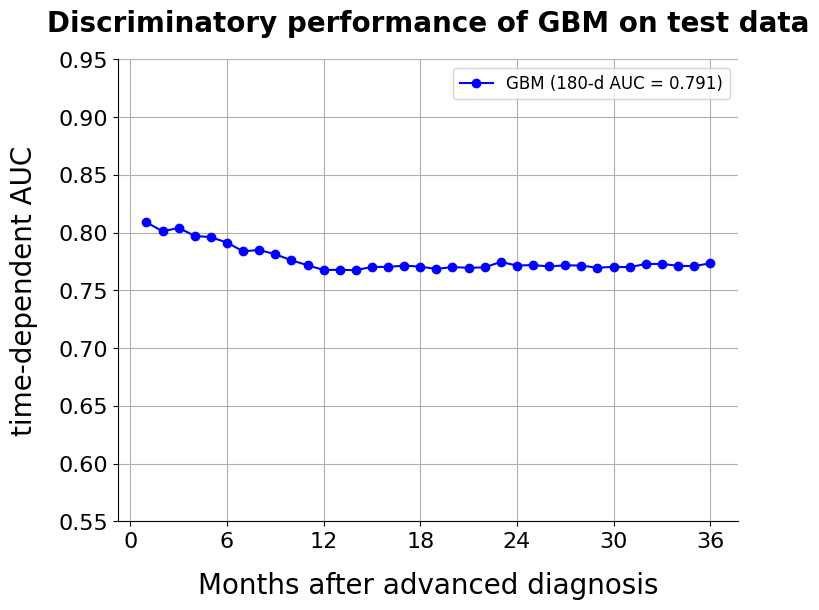

In [40]:
fig, ax0 = plt.subplots(figsize=(8, 6))

# Discriminatory performance plot
times = np.arange(30, 1095, 30)

ax0.plot(times/30, 
         gbm_auc_over5_df.loc['gbm'].values[0:36], 
         'o-', 
         color = 'blue', 
         label = f"GBM (180-d AUC = {final_auc_test:.3f})")

ax0.set_xticks(np.arange(0, 37, 6))
ax0.set_yticks(np.arange(0.55, 1.0, 0.05))
ax0.tick_params(axis = 'both', which = 'major', labelsize = 16) 

ax0.set_title('Discriminatory performance of GBM on test data', weight = 'bold', size = 20, pad = 20)
ax0.set_xlabel('Months after advanced diagnosis', labelpad = 15, size = 20)
ax0.set_ylabel('time-dependent AUC', labelpad = 15, size = 20)
ax0.legend(loc = 'upper right', prop = {'size': 12})
ax0.grid(True)

ax0.spines['top'].set_visible(False)
ax0.spines['right'].set_visible(False)

plt.show()

Total number of features: 115
Number of non-zero features in final model: 122


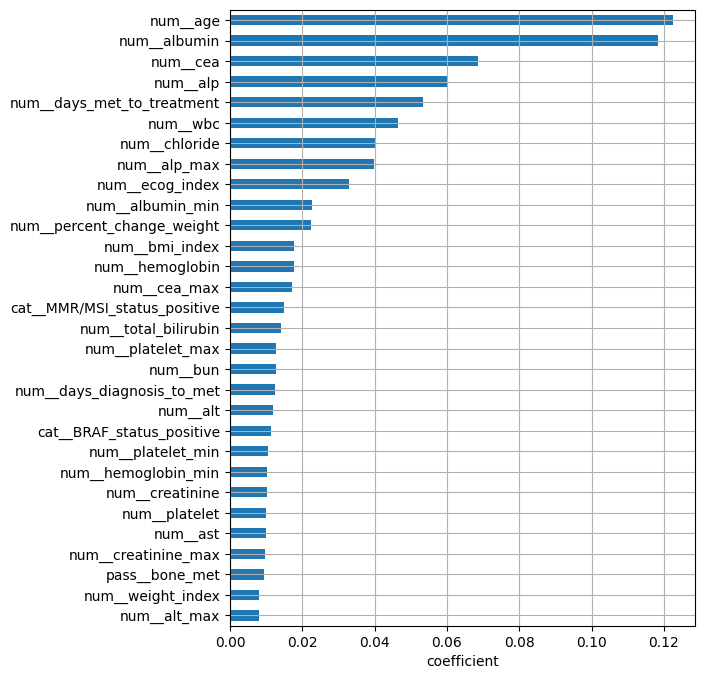

In [41]:
# Dataframe of coefficients for each variable 
gbm_feature_importance = pd.DataFrame(
    full_pipeline_final.named_steps['model'].feature_importances_,
    index = full_pipeline_final.named_steps['preprocessor'].get_feature_names_out(),
    columns = ['coefficient']
)

print('Total number of features: {}'.format(len(all_var)))

non_zero = np.sum(gbm_feature_importance.iloc[:, 0] != 0)
print('Number of non-zero features in final model: {}'.format(non_zero))

non_zero_coefs = gbm_feature_importance.query('coefficient != 0')
coef_order = non_zero_coefs.abs().sort_values('coefficient').tail(30).index

_, ax = plt.subplots(figsize=(6, 8))
non_zero_coefs.loc[coef_order].plot.barh(ax = ax, legend = False)
ax.set_xlabel('coefficient')
ax.grid(True)

In [42]:
gbm_feature_importance = (
    gbm_feature_importance
    .reset_index()
    .rename(columns = {'index':'variable'})
)

In [43]:
gbm_feature_importance.to_csv('../outputs/gbm_feature_importance.csv', index = False, header = True)

## Calculating survival probabilities
**Survival probabilities are calculated for each patient using 3-fold cross-validation. For each fold, a model is trained on 67% of the data, and survival probabilities are generated for patients in the held-out 33%. This approach ensures that each patient's survival probability is based on a model that does not include them in training, providing unbiased predictions.**

### Preprocessing

In [44]:
df = pd.concat([train_df, test_df])

In [45]:
df.shape

(37381, 200)

In [46]:
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [47]:
model_params = {
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 4,
    'subsample': 0.85,
    'max_features': 0.9,
    'verbose': 1,
    'random_state': 42
}

cv_scores_df = cross_validated_survival_predictions(
    df = df,                      
    y = y,                      
    all_var = all_var,                 
    preprocessor = preprocessor,            
    model_params = model_params,            
    survival_timepoints = (180, 365),     
    tau = 365,                     
    n_splits = 3,              
    random_state = 42,         
    verbose = True  
)

Processing fold 1/3
      Iter       Train Loss      OOB Improve   Remaining Time 
         1      129582.9945          14.4535           63.64m
         2      129417.5916         -65.8996           63.05m
         3      129722.5395         327.5029           62.86m
         4      129445.8911        -141.1176           62.65m
         5      129558.9946         160.4612           62.44m
         6      129002.2015        -380.8335           62.28m
         7      129140.1893         172.8657           62.13m
         8      129267.1979         150.4350           62.01m
         9      129381.3850         147.2381           61.85m
        10      128960.1820        -272.5571           61.70m
        20      128378.4342         -89.8574           60.25m
        30      128074.0796         -42.8112           58.63m
        40      127864.8424         125.5366           57.39m
        50      128044.6704         499.1783           56.31m
        60      127534.3435         118.3327     

In [48]:
cv_scores_df.to_csv('../outputs/gb_survival_predictions.csv')